# 🎙️ Denoising Autoencoder: Cancelación de Ruido de Voz

## 1. Caso de Uso

Implementación de un modelo basado en Autoencoders para limpiar y eliminar el ruido de fondo de grabaciones de voz, simulando el motor de audio de aplicaciones de comunicación como Discord o Zoom.

**Dataset:** Para entrenar la red, utilizaremos el **Speech Noise Dataset** que proporciona audios ya estructurados en carpetas de voz limpia (`clean_speech`), ruido ambiente (`noise_only`) y la mezcla de ambos (`noisy_speech`). Esto nos proporciona los pares exactos de "señal ruidosa vs señal limpia" necesarios para que el Autoencoder aprenda a reconstruir la voz humana ignorando las frecuencias caóticas.

In [14]:
import os
import shutil
import kagglehub

# Ruta local
local_data_dir = os.path.join(os.getcwd(), "..", "data")
dataset_name = "abdullahhaydarkadolu/speech-noise-dataset"

# Descargar con kagglehub
download_path = kagglehub.dataset_download(dataset_name)

# Mover los archivos a la ruta local
if not os.path.exists(local_data_dir):
    os.makedirs(local_data_dir)

# Movemos el dataset a la ruta local
if len(os.listdir(local_data_dir)) == 0:
    for item in os.listdir(download_path):
        s = os.path.join(download_path, item)
        d = os.path.join(local_data_dir, item)
        if os.path.isdir(s):
            shutil.copytree(s, d)
        else:
            shutil.copy2(s, d)
    print(f"¡Hecho! Dataset listo en tu carpeta local: {local_data_dir}")
else:
    print("Los datos ya están presentes en la carpeta local 'data'. Saltando paso.")   

¡Hecho! Dataset listo en tu carpeta local: c:\Users\Alumno_AI\Desktop\voice-denoising-autoencoder\notebooks\..\data


## 2. Transformación de Audio a Imágenes (Espectrogramas)

Las redes neuronales convolucionales están diseñadas para procesar datos en dos dimensiones, no ondas de audio unidimensionales. Por lo que debemos transformar nuestros archivos `.wav` en **espectrogramas**.

Un espectrograma es una representación visual del sonido:
- **Eje X:** Tiempo.
- **Eje Y:** Frecuencia (Hz).
- **Color:** Intensidad o volumen (Decibelios).

### 1. Función para pasar de audio a espectrograma

Para cumplir con el preprocesado de datos exigido, usaremos la librería `librosa` para calcular la Transformada Rápida de Fourier (STFT), normalizar los valores entre 0 y 1, y guardar las matrices en formato `.npy` (Numpy), lo cual acelerará drásticamente el entrenamiento de nuestro Autoencoder.

In [15]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# Rutas origen
clean_dir = os.path.join(local_data_dir, "speech-noise-dataset/clean_speech")
noisy_dir = os.path.join(local_data_dir, "speech-noise-dataset/noisy_speech")

# Rutas destino (espectrogramas)
output_clean_dir = os.path.join(local_data_dir, "processed_clean")
output_noisy_dir = os.path.join(local_data_dir, "processed_noisy")
os.makedirs(output_clean_dir, exist_ok=True)
os.makedirs(output_noisy_dir, exist_ok=True)

def audio_to_spectrogram(audio_path, output_path, n_fft=1024, hop_length=256):
    try:
        # Cargamos el audio a 16kHz
        y, sr = librosa.load(audio_path, sr=16000)

        # Homogeneizamos la longitud (2s) para que todos los espectrogramas tengan el mismo tamaño al entrar a la red
        target_length = 32000
        if len(y) > target_length:
            y = y[:target_length]
        else:
            y = np.pad(y, (0, max(0, target_length - len(y))), "constant")

        # Calculamos STFT y pasamos a decibelios
        stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
        spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

        # Normalizamos
        spectrogram = (spectrogram - spectrogram.min()) / (spectrogram.max() - spectrogram.min() + 1e-8)

        # Guardamos el espectrograma
        np.save(output_path, spectrogram)
        return True
    except Exception as e:
        print(f"Error en {audio_path}: {e}")
        return False

### 2. Procesamiento Masivo del Dataset

A continuación, iteramos sobre nuestra carpeta de datos. Es crucial asegurarnos de emparejar correctamente cada archivo de voz ruidosa con su equivalente en voz limpia. Solo procesaremos un archivo si tenemos ambas versiones, garantizando así la correspondencia exacta *(X -> Y)* que el Autoencoder necesita para aprender a limpiar el ruido.

In [16]:
# Archivos disponibles
archivos_limpios = [f for f in os.listdir(clean_dir) if f.endswith(".wav")]
procesados = 0

print(f"Iniciando transformación de archivos...")

for archivo in archivos_limpios:
    path_clean = os.path.join(clean_dir, archivo)
    path_noisy = os.path.join(noisy_dir, archivo)

    out_clean = os.path.join(output_clean_dir, archivo.replace(".wav", ".npy"))
    out_noisy = os.path.join(output_noisy_dir, archivo.replace(".wav", ".npy"))

    # Comprobamos que el par ruidoso existe
    if os.path.exists(path_noisy):
        # Transformamos ambos
        ok_c = audio_to_spectrogram(path_clean, out_clean)
        ok_n = audio_to_spectrogram(path_noisy, out_noisy)

        if ok_c and ok_n:
            procesados += 1

    if procesados % 200 == 0 and procesados > 0:
        print(f"-> {procesados} pares de espectrogramas procesados...")

print("✅ Preprocesado completado con éxito.")

Iniciando transformación de archivos...
-> 200 pares de espectrogramas procesados...
-> 400 pares de espectrogramas procesados...
-> 600 pares de espectrogramas procesados...
-> 800 pares de espectrogramas procesados...
-> 1000 pares de espectrogramas procesados...
-> 1200 pares de espectrogramas procesados...
✅ Preprocesado completado con éxito.


### 3. Verificación Visual

Antes de construir la arquitectura del Autoencoder, vamos a graficar uno de los pares procesados. Lo que nos permitirá entender cómo ve los datos nuestro modelo.

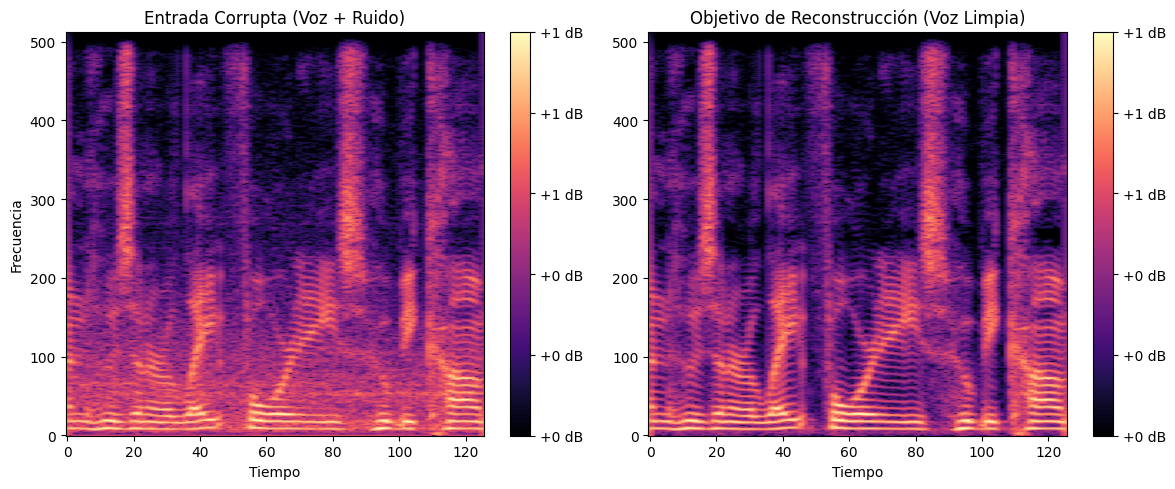

Forma del espectrograma (Input Shape): (513, 126)


In [17]:
import random

# Archivo aleatorio de los procesados
archivos_npy = os.listdir(output_clean_dir)
ejemplo = random.choice(archivos_npy)

# Cargamos las matrices
spec_clean = np.load(os.path.join(output_clean_dir, ejemplo))
spec_noisy = np.load(os.path.join(output_noisy_dir, ejemplo))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Entrada Corrupta (Voz + Ruido)")
plt.imshow(spec_noisy, aspect='auto', origin='lower', cmap='magma') 
plt.ylabel("Frecuencia")
plt.xlabel("Tiempo")
plt.colorbar(format='%+2.0f dB')
plt.subplot(1, 2, 2)
plt.title("Objetivo de Reconstrucción (Voz Limpia)")
plt.imshow(spec_clean, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

print(f"Forma del espectrograma (Input Shape): {spec_clean.shape}")

### Conclusiones

Al observar la gráfica generada, podemos confirmar el éxito del preprocesamiento:
1. **Entrada Corrupta (Izquierda):** Se aprecia cómo las frecuencias bajas (la parte inferior del gráfico, entre 0 y 100 Hz) están "sucias" con una franja anaranjada continua. Esto representa el ruido de fondo constante que interfiere con la señal principal.
2. **Objetivo de Reconstrucción (Derecha):** En la señal limpia, esa franja inferior de ruido desaparece, dejando un fondo negro (silencio) y destacando únicamente los picos de energía que corresponden a la voz humana.

El trabajo de nuestro Autoencoder será precisamente aprender a transformar la imagen de la izquierda en la de la derecha.

**Definición de Dimensiones:**
El código nos ha devuelto que la forma del espectrograma es `(513, 126)`. 
* `513` corresponde a las bandas de frecuencia (Eje Y).
* `126` corresponde a los fragmentos de tiempo (Eje X).
* Como estamos procesando imágenes en blanco y negro (aunque apliquemos un mapa de color para verlo mejor), añadiremos un canal al final.

Por lo tanto, la dimensión de entrada para nuestra primera capa en Keras será: `(513, 126, 1)`.

## 3. Arquitectura del Denoising Autoencoder

A continuación, implementamos la red neuronal, que constará de tres partes fundamentales:

1. **Encoder:** Utiliza capas convolucionales (`Conv2D`) y de agrupamiento (`MaxPooling2D`) para reducir la dimensionalidad espacial del espectrograma, extrayendo las características esenciales como las frecuencias vocales, y descartando el ruido.
2. **Bottleneck:** Es el punto de máxima compresión. Controlar la capacidad aquí es muy importante, ya que si es muy grande la red memorizará el ruido. Pero si es muy pequeño, perderemos calidad de voz quedando un efecto robótico.
3. **Decoder:** Utiliza convoluciones y submuestreo (`UpSampling2D`) para expandir el espacio latente y reconstruir el espectrograma limpio.

Debido a que nuestra entrada original tiene dimensiones `(513, 126, 1)`, que no son divisibles entre 2, es necesario incluir capas de redimensionamiento (`Resizing`) al principio para redimensionar a `(512, 128, 1)` y al final de nuevo a `(513, 126, 1)`. Así descartamos posibles desajustes de tamaño durante el proceso. 

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Input shape del preprocesamiento
input_shape = (513, 126, 1)
inputs = keras.Input(shape=input_shape, name="espectrograma_corrupto")

# Resizing para evitar desajustes
x = layers.Resizing(512, 128, name="ajuste_entrada")(inputs)

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same", name="bottleneck")(x)

# Decoder
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)

# Output con sigmoid (valores normalizados)
x = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# Resizing al tamaño original
decoded = layers.Resizing(513, 126, name="ajuste_salida")(x)

# Compilamos el modelo con MSE para medir el error de reconstrucción
autoencoder = keras.Model(inputs, decoded, name="Denoising_Autoencoder_Audio")
autoencoder.compile(optimizer="adam", loss="mse", metrics=["mae"])

autoencoder.summary()

Model: "Denoising_Autoencoder_Audio"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ espectrograma_corrupto          │ (None, 513, 126, 1)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ajuste_entrada (Resizing)       │ (None, 512, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 512, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 256, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 256, 64, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 32, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 32, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 64, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 128, 32, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 32, 64)    │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 256, 64, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 256, 64, 32)    │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 512, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 512, 128, 1)    │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ajuste_salida (Resizing)        │ (None, 513, 126, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento del Modelo

### 1. Carga de Datos y División (Train / Val / Test)

Cabe recordar que nuestros datos a usar son los procesados en lugar de los originales del dataset:
* **X (Entrada):** Los espectrogramas con ruido (`processed_noisy`).
* **Y (Objetivo):** Los espectrogramas limpios (`processed_clean`).

In [18]:
from sklearn.model_selection import train_test_split

# Archivos disponibles
archivos = sorted(os.listdir(output_clean_dir))

X_lista = []
Y_lista = []

for archivo in archivos:
    path_n = os.path.join(output_noisy_dir, archivo)
    path_c = os.path.join(output_clean_dir, archivo)
    
    if os.path.exists(path_n) and os.path.exists(path_c):
        X_lista.append(np.load(path_n))
        Y_lista.append(np.load(path_c))

# Espectrogramas -> Tensores
X = np.array(X_lista)
Y = np.array(Y_lista)

# Añadimos la dimensión del canal necesaria para Conv2D
X = np.expand_dims(X, axis=-1)
Y = np.expand_dims(Y, axis=-1)

# Separación en train (80%) y temp (20%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)

# Separación de temp en validación (10%) y test (10%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print(f"Datos de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de Validación: {X_val.shape[0]} muestras")
print(f"Datos de Test: {X_test.shape[0]} muestras")

Datos de Entrenamiento: 973 muestras
Datos de Validación: 122 muestras
Datos de Test: 122 muestras


### 2. Entrenamiento del Modelo

Con los datos listos, procedemos a entrenar el autoencoder implementando `EarlyStopping` con un CallBack, que monitorize el error de validación (`val_loss`) para evitar el overfitting.

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Hiperparámetros
EPOCHS = 30
BATCH_SIZE = 16

# Entrenamiento
history = autoencoder.fit(
    x=X_train,
    y=Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

autoencoder.save("../models/denoising_autoencoder.keras")
print("\nModelo entrenado y guardado correctamente.")

Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 31s 482ms/step - loss: 0.0350 - mae: 0.1453 - val_loss: 0.0171 - val_mae: 0.1003
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 484ms/step - loss: 0.0154 - mae: 0.0952 - val_loss: 0.0137 - val_mae: 0.0888
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 473ms/step - loss: 0.0126 - mae: 0.0853 - val_loss: 0.0120 - val_mae: 0.0841
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 489ms/step - loss: 0.0113 - mae: 0.0804 - val_loss: 0.0108 - val_mae: 0.0786
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 473ms/step - loss: 0.0108 - mae: 0.0783 - val_loss: 0.0105 - val_mae: 0.0754
Epoch 6/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 479ms/step - loss: 0.0103 - mae: 0.0762 - val_loss: 0.0108 - val_mae: 0.0760
Epoch 7/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 496ms/step - loss: 0.0100 - mae: 0.0750 - val_loss: 0.0099 - val_mae: 0.0752
Epoch 8/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 483ms/step - loss: 0.0098 - mae: 0.0740 - val_loss: 0.0093 - val_mae: 0.0712
Epoch 9/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 480ms/

### 3. Evaluación del Modelo con Test

El modelo se ha entrenado correctamente y el `EarlyStopping` se activó restableciendo los pesos a los de la epoch 28, pero para medir su rendimiento real debemos evaluarlo con el conjunto de `Test`.

In [8]:
from tensorflow.keras.models import load_model

autoencoder = load_model("../models/denoising_autoencoder.keras")
test_loss, test_mae = autoencoder.evaluate(X_test, Y_test, verbose=1)

print(f"Error Cuadrático Medio (MSE) en Test: {test_loss:.4f}")
print(f"Error Absoluto Medio (MAE) en Test: {test_mae:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step - loss: 0.0076 - mae: 0.0636
Error Cuadrático Medio (MSE) en Test: 0.0076
Error Absoluto Medio (MAE) en Test: 0.0636


**Conclusión de Rendimiento:**
- **Generalización:** El `mse` en Test (0.0076) es prácticamente el mismo al `val_mae` con el que terminó el entrenamiento, lo que demuestra que el modelo ha aprendido a limpiar el ruido genérico en lugar de memorizar los audios de entrenamiento.
- **Fidelidad Acústica:** El `mae` de 0.0636 nos indica que, el modelo tiene un desajuste promedio de un **~6.3%** normalizado al predecir el color de cada píxel, que representa la intensidad de cada frecuencia. Transfiriendo esto a audio, garantiza una voz reconstruida altamente nítida y fiel a la original.

### 4. Demostración Visual

La mejor forma de evaluar un Denoising Autoencoder es viendo cómo limpia la señal visualmente. A continuación, tomaremos un espectrograma aleatorio del conjunto de test con ruido, le pediremos al modelo que lo limpie mediante una predicción, y compararemos el resultado con el objetivo original.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


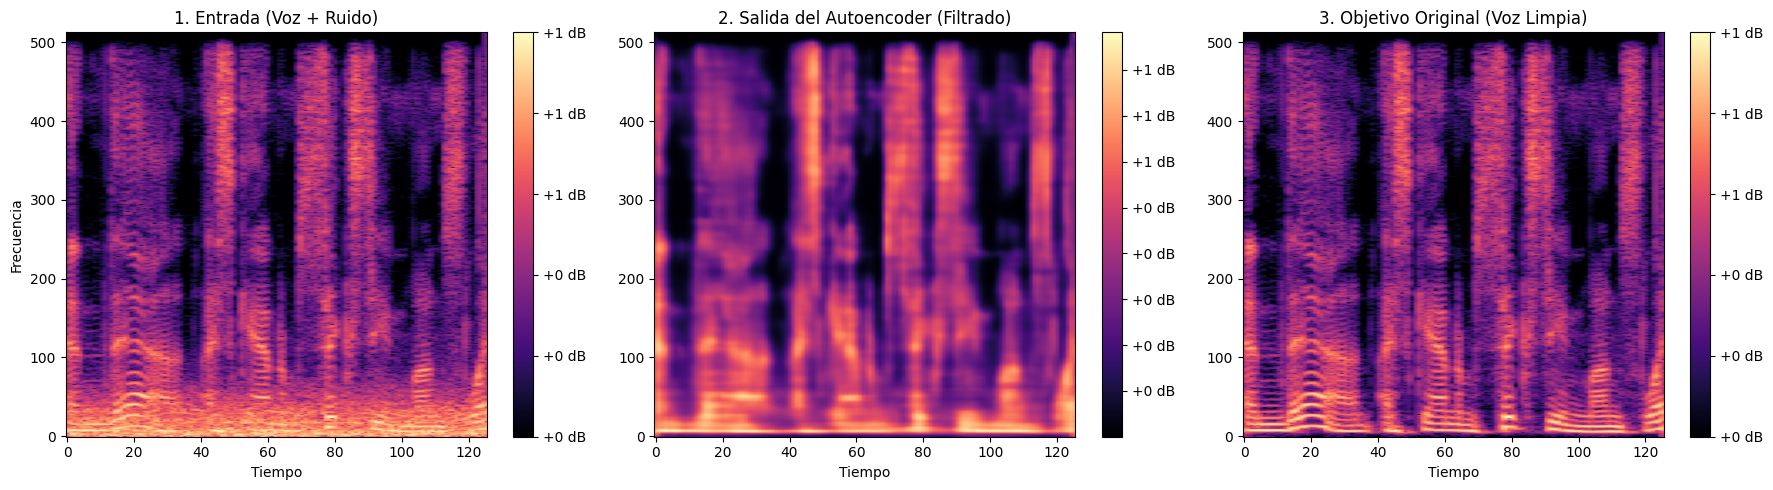

In [9]:
# Indice aleatorio de test
idx = random.randint(0, len(X_test) - 1)

# Extraemos la entrada ruidosa y limpia
sample_corrupto = np.expand_dims(X_test[idx], axis=0)
sample_limpio = Y_test[idx]

# Lo pasamos por el modelo
prediccion = autoencoder.predict(sample_corrupto)

# Quitamos la dimensión del batch y del canal para poder dibujarlos
img_corrupta = np.squeeze(sample_corrupto)
img_prediccion = np.squeeze(prediccion)
img_limpia = np.squeeze(sample_limpio)

plt.figure(figsize=(18, 5))

# Con Ruido
plt.subplot(1, 3, 1)
plt.title("1. Entrada (Voz + Ruido)")
plt.imshow(img_corrupta, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia")
plt.colorbar(format='%+2.0f dB')

# Predicción del Autoencoder
plt.subplot(1, 3, 2)
plt.title("2. Salida del Autoencoder (Filtrado)")
plt.imshow(img_prediccion, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")
plt.colorbar(format='%+2.0f dB')

# Limpia
plt.subplot(1, 3, 3)
plt.title("3. Objetivo Original (Voz Limpia)")
plt.imshow(img_limpia, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

**Conclusión Visual**

Al observar las tres gráficas, podemos confirmar visualmente el éxito del modelo y extraer conclusiones técnicas importantes como:

- **Eliminación de Ruido:** El Autoencoder ha logrado limpiar casi por completo la franja inferior `(ruido de baja frecuencia)` y las interferencias estáticas del fondo, devolviendo el lienzo a un tono oscuro muy similar al objetivo.
- **Efecto de Suavizado:** Notamos que la predicción `(espectrograma del centro)` está más difuminada que la voz real `(espectrograma de la derecha)`. Esto es un efecto secundario que ocurre por dos motivos:
    1. La compresión extrema en el bottleneck hace que se pierdan los detalles de más alta frecuencia.
    2. El uso de la función de pérdida `mse` tiende a promediar las predicciones, generando resultados más suaves y menos nítidos.

## 5. Intento de Mejora (cGAN)

### 1. Arquitectura

Vamos a intentar mejorar el modelo transformándolo en una cGAN, utilizando nuestro Autoencoder como Generador. El objetivo es eliminar el efecto robótico de la voz introduciendo un Discriminador, que obligará al Generador a crear voces naturales, ya que castigará cualquier resultado que no se parezca a las voces limpias que usaremos como referencia.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

generator = autoencoder

def build_discriminator():
    inp = layers.Input(shape=(513, 126, 1), name='espectrograma_evaluar')
    
    # Ajuste de dimensiones a potencias de 2 para las convoluciones
    x = layers.Resizing(512, 128)(inp)
    
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Flatten()(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    
    return Model(inp, out, name="Discriminador")

discriminator = build_discriminator()

discriminator.summary()

c:\Users\Alumno_AI\Desktop\voice-denoising-autoencoder\venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Discriminador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ espectrograma_evaluar           │ (None, 513, 126, 1)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 512, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 64, 64)    │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256, 64, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 32, 128)   │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128, 32, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 16, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       262,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 918,977 (3.51 MB)

 Trainable params: 918,977 (3.51 MB)

 Non-trainable params: 0 (0.00 B)

### 2. Entrenamiento

In [20]:
import os

# Optimizadores
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
loss_fn = tf.keras.losses.BinaryCrossentropy()

@tf.function
def train_step(espectrograma_ruidoso, espectrograma_limpio):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        
        # Generamos el espectrograma limpio
        espectrograma_generado = generator(espectrograma_ruidoso, training=True)
        
        # Lo evaluamos
        veredicto_real = discriminator(espectrograma_limpio, training=True)
        veredicto_generado = discriminator(espectrograma_generado, training=True)
        
        # Afinamos la pérdida del discriminador
        loss_disc_real = loss_fn(tf.ones_like(veredicto_real), veredicto_real)
        loss_disc_generado = loss_fn(tf.zeros_like(veredicto_generado), veredicto_generado)
        disc_loss = loss_disc_real + loss_disc_generado
        
        # Afinamos la pérdida del generador (Adversarial + Fidelidad L1)
        gen_adversarial_loss = loss_fn(tf.ones_like(veredicto_generado), veredicto_generado)
        gen_l1_loss = tf.reduce_mean(tf.abs(espectrograma_limpio - espectrograma_generado))
        
        # Damos más peso a la fidelidad para mantener la estructura de la voz
        gen_loss = gen_adversarial_loss + (100 * gen_l1_loss) 

    # Actualizamos los pesos
    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    
    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

BATCH_SIZE = 16
dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(BATCH_SIZE)
total_steps = len(dataset)

EPOCHS_GAN = 50

for epoch in range(EPOCHS_GAN):
    print(f"\n--- Época {epoch+1}/{EPOCHS_GAN} ---")
    
    for step, (batch_ruido, batch_limpio) in enumerate(dataset):
        g_loss, d_loss = train_step(batch_ruido, batch_limpio)
        
        if step == total_steps - 1:
            print(f"| Loss Generador: {g_loss:.4f} | Loss Discriminador: {d_loss:.4f}")

# Guardar el modelo final
ruta_modelo_gan = os.path.join(local_data_dir, "../models/denoising_cGAN.keras")
generator.save(ruta_modelo_gan)
print(f"✅ Entrenamiento cGAN completado y guradado en {ruta_modelo_gan}.")


--- Época 1/50 ---
| Loss Generador: 12.6023 | Loss Discriminador: 0.1646

--- Época 2/50 ---
| Loss Generador: 14.5347 | Loss Discriminador: 0.0706

--- Época 3/50 ---
| Loss Generador: 13.6468 | Loss Discriminador: 0.1604

--- Época 4/50 ---
| Loss Generador: 15.0646 | Loss Discriminador: 0.0904

--- Época 5/50 ---
| Loss Generador: 16.6954 | Loss Discriminador: 0.1990

--- Época 6/50 ---
| Loss Generador: 17.1110 | Loss Discriminador: 0.1139

--- Época 7/50 ---
| Loss Generador: 14.4906 | Loss Discriminador: 0.0820

--- Época 8/50 ---
| Loss Generador: 13.9761 | Loss Discriminador: 0.5159

--- Época 9/50 ---
| Loss Generador: 12.6829 | Loss Discriminador: 0.1611

--- Época 10/50 ---
| Loss Generador: 12.1443 | Loss Discriminador: 0.4004

--- Época 11/50 ---
| Loss Generador: 12.5292 | Loss Discriminador: 0.2229

--- Época 12/50 ---
| Loss Generador: 13.1463 | Loss Discriminador: 0.1430

--- Época 13/50 ---
| Loss Generador: 13.2606 | Loss Discriminador: 0.1665

--- Época 14/50 ---


### 3. Resultados

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


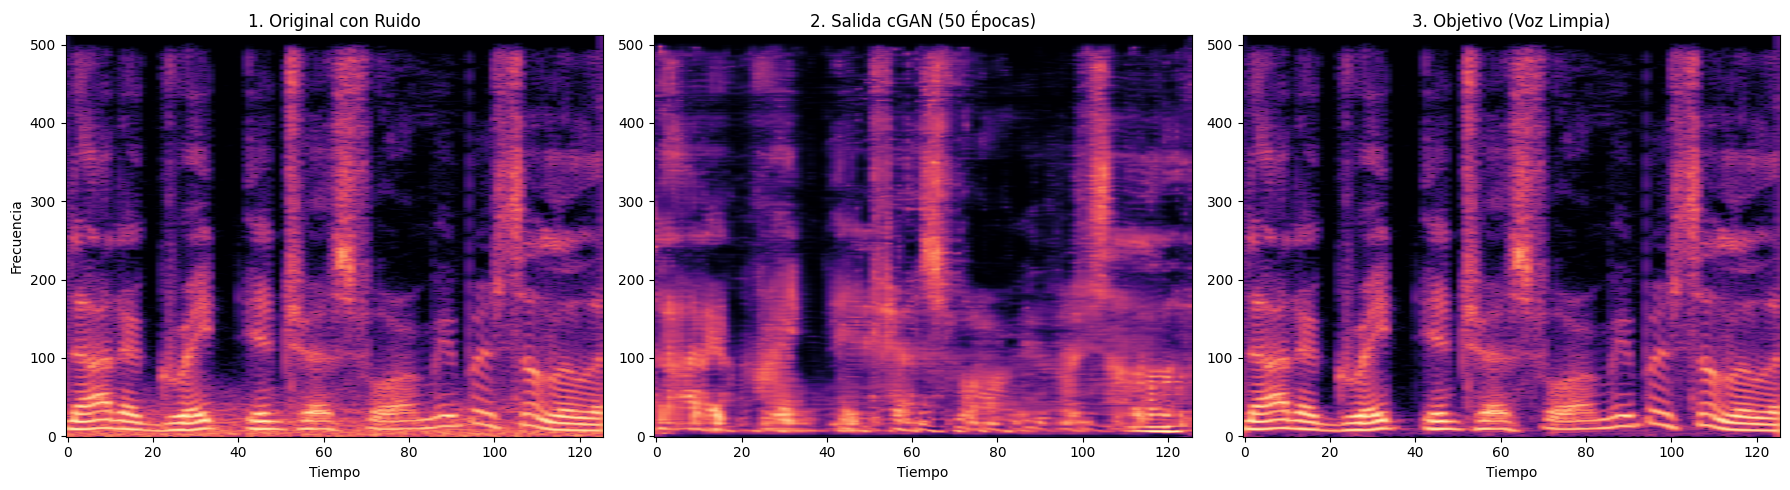

In [24]:
import matplotlib.pyplot as plt
import random
import numpy as np

# Cargamos el modelo de la cGAN
generador_cgan = tf.keras.models.load_model("../models/denoising_cGAN.keras", compile=False)

# Seleccionamos un audio aleatorio de Test
idx = random.randint(0, len(X_test) - 1)
sample_corrupto = np.expand_dims(X_test[idx], axis=0)
sample_limpio = Y_test[idx]

# Predicción con la cGAN
prediccion_cgan = generador_cgan.predict(sample_corrupto)

# Preparamos las imágenes
img_corrupta = np.squeeze(sample_corrupto)
img_prediccion = np.squeeze(prediccion_cgan)
img_limpia = np.squeeze(sample_limpio)


plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)

plt.title("1. Original con Ruido")
plt.imshow(img_corrupta, aspect='auto', origin='lower', cmap='magma')
plt.ylabel("Frecuencia")
plt.xlabel("Tiempo")

plt.subplot(1, 3, 2)
plt.title("2. Salida cGAN (50 Épocas)")
plt.imshow(img_prediccion, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")

plt.subplot(1, 3, 3)
plt.title("3. Objetivo (Voz Limpia)")
plt.imshow(img_limpia, aspect='auto', origin='lower', cmap='magma')
plt.xlabel("Tiempo")

plt.tight_layout()
plt.show()

**Conclusión**

- **Formantes súper marcados:** Las líneas horizontales brillantes de la parte inferior representan la voz, que ya no está tan difuminado.

- **Silencios reales:** Las columnas verticales negras que representan los silencios son prácticamente "negro puro". La cGAN se ha atrevido a apagar completamente la señal en lugar de dejar esa neblilla gris de inseguridad que dejaba el MSE clásico.

## 6. Intento de Mejora (Vocoder Neuronal)

Con el objetivo de mejorar el audio resultante vamos a añadir un **Vocoder Neuronal**, que creará una fase acorde al espectrograma limpio que hará que no se escuche robótico.

Para ello tenemos que:
- **Repetir el Preprocesamiento**: Los **Vocoder Neuronal** usan Espectrogramas de Mel en lugar de los Espectrogramas Lineales que estabamos usando antes. Estos tienen 80 bandas de frequencia por lo que tienen forma `(80, 126, 1)` en lugar de `(513, 126, 1)`.
- **Repetir el Entrenamiento**: Al tener diferente forma, la cGAN que tenemos actualmente no nos sirve, ya que el input tiene una forma diferente a la de los Espectrogramas de Mel.
- 

### 1. Preprocesamiento

In [39]:
import os
import numpy as np
import librosa
from tqdm import tqdm

# ===================================================
# LA RECETA EXACTA DE MICROSOFT PARA HIFI-GAN
# ===================================================
SAMPLE_RATE = 16000
N_MELS = 80
N_FFT = 1024
HOP_LENGTH = 256
WIN_LENGTH = 1024
FMIN = 0.0
FMAX = 8000.0

# Valores para normalizar el Logaritmo Natural a [0, 1] para la cGAN
MIN_MEL = -11.5129  # Equivalente matemático a np.log(1e-5)
MAX_MEL = 2.0       # Tope aproximado de la voz humana en log-mel
RANGO_MEL = MAX_MEL - MIN_MEL

def procesar_audio_vocoder_librosa(ruta_audio):
    # 1. Cargar audio forzando los 16kHz
    y, _ = librosa.load(ruta_audio, sr=SAMPLE_RATE)
    
    # 2. Calcular la STFT (Magnitud pura, power=1.0, NO al cuadrado)
    magnitud = np.abs(librosa.stft(
        y, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH
    ))
    
    # 3. Crear y aplicar los filtros de Mel (de 0 a 8000 Hz)
    mel_basis = librosa.filters.mel(
        sr=SAMPLE_RATE, n_fft=N_FFT, n_mels=N_MELS, fmin=FMIN, fmax=FMAX
    )
    mel_spec = np.dot(mel_basis, magnitud)
    
    # 4. Logaritmo Natural (Truncado para evitar el logaritmo de cero)
    mel_log = np.log(np.clip(mel_spec, a_min=1e-5, a_max=None))
    
    # 5. Rellenar o recortar a 128 columnas (aprox 2 segundos)
    if mel_log.shape[1] > 128:
        mel_log = mel_log[:, :128]
    else:
        pad_width = 128 - mel_log.shape[1]
        mel_log = np.pad(mel_log, pad_width=((0, 0), (0, pad_width)), mode='constant', constant_values=MIN_MEL)
        
    # 6. Normalizar a rango [0, 1] para la función Sigmoide de tu cGAN
    mel_norm = (mel_log - MIN_MEL) / RANGO_MEL
    mel_norm = np.clip(mel_norm, 0.0, 1.0)
    
    # 7. Formato final para Keras: (Alto, Ancho, Canales) -> (80, 128, 1)
    return np.expand_dims(mel_norm, axis=-1)

def crear_dataset_vocoder(dir_ruido, dir_limpio):
    X_data, Y_data = [], []
    archivos = sorted(os.listdir(dir_ruido))
    
    print("🎙️ Fabricando Espectrogramas Log-Mel exactos para HiFi-GAN...")
    for archivo in tqdm(archivos):
        if archivo.endswith('.wav'):
            ruta_ruido = os.path.join(dir_ruido, archivo)
            ruta_limpio = os.path.join(dir_limpio, archivo)
            
            X_data.append(procesar_audio_vocoder_librosa(ruta_ruido))
            Y_data.append(procesar_audio_vocoder_librosa(ruta_limpio))
            
    return np.array(X_data), np.array(Y_data)

# --- EJECUCIÓN ---
DIR_RUIDO = "../data/speech-noise-dataset/noisy_speech"
DIR_LIMPIO = "../data/speech-noise-dataset/clean_speech"

X_mel_vocoder, Y_mel_vocoder = crear_dataset_vocoder(DIR_RUIDO, DIR_LIMPIO)

print("-" * 30)
print(f"✅ Datos listos.")
print(f"Dimensiones de X: {X_mel_vocoder.shape}")

🎙️ Fabricando Espectrogramas Log-Mel exactos para HiFi-GAN...


100%|██████████| 1217/1217 [00:50<00:00, 24.26it/s]


------------------------------
✅ Datos listos.
Dimensiones de X: (1217, 80, 128, 1)


### 2. Nueva Arquitectura

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import os

# Generador
def build_generator():
    inputs = layers.Input(shape=(80, 128, 1), name="entrada_mel_ruidosa")
    
    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    
    # Espacio Latente
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    
    # Decoder
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    
    x = layers.UpSampling2D((2, 2))(x)
    
    # Salida
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    return Model(inputs, outputs, name="Generador_HiFiGAN")

# Discriminador
def build_discriminator():
    inp = layers.Input(shape=(80, 128, 1), name='mel_evaluar')
    
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same')(inp)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    
    x = layers.Flatten()(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    
    return Model(inp, out, name="Discriminador_HiFiGAN")

generator_hifi = build_generator()
discriminator_hifi = build_discriminator()

generator_hifi.summary()
discriminator_hifi.summary()

c:\Users\Alumno_AI\Desktop\voice-denoising-autoencoder\venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Generador_HiFiGAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_mel_ruidosa             │ (None, 80, 128, 1)     │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 80, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 40, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 40, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 20, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 40, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 40, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 80, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 80, 128, 1)     │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,041 (652.50 KB)

 Trainable params: 167,041 (652.50 KB)

...

Model: "Discriminador_HiFiGAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_evaluar (InputLayer)        │ (None, 80, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 40, 64, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 40, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 20, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 20, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 10, 16, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 10, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 40960)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        40,961 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 697,793 (2.66 MB)

 Trainable params: 697,793 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Entrenamiento de la cGNA

In [41]:
import os

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
loss_fn = tf.keras.losses.BinaryCrossentropy()

@tf.function
def train_step(mel_ruidoso, mel_limpio):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generamos el espectrograma limpio
        mel_generado = generator_hifi(mel_ruidoso, training=True)
        
        # Lo evaluamos
        veredicto_real = discriminator_hifi(mel_limpio, training=True)
        veredicto_generado = discriminator_hifi(mel_generado, training=True)
        
        # Pérdida del Discriminador
        loss_disc_real = loss_fn(tf.ones_like(veredicto_real), veredicto_real)
        loss_disc_generado = loss_fn(tf.zeros_like(veredicto_generado), veredicto_generado)
        disc_loss = loss_disc_real + loss_disc_generado
        
        # Pérdida del Generador
        gen_adversarial_loss = loss_fn(tf.ones_like(veredicto_generado), veredicto_generado)
        gen_l1_loss = tf.reduce_mean(tf.abs(mel_limpio - mel_generado))
        
        # Damos más peso a la Fidelidad
        gen_loss = gen_adversarial_loss + (100 * gen_l1_loss) 

    # Actualizamos pesos
    gen_gradients = gen_tape.gradient(gen_loss, generator_hifi.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator_hifi.trainable_variables)
        
    generator_optimizer.apply_gradients(zip(gen_gradients, generator_hifi.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator_hifi.trainable_variables))
    
    return gen_loss, disc_loss

# Usamos las NUEVAS variables del dataset compatible con el Vocoder
BATCH_SIZE = 16
dataset_hifi = tf.data.Dataset.from_tensor_slices((X_mel_vocoder, Y_mel_vocoder)).batch(BATCH_SIZE)
total_steps = len(dataset_hifi)

#Entrenamiento
EPOCHS = 50

for epoch in range(EPOCHS):
    print(f"--- Época {epoch+1}/{EPOCHS} ---", end=" ")
    for step, (batch_ruido, batch_limpio) in enumerate(dataset_hifi):
        g_loss, d_loss = train_step(batch_ruido, batch_limpio)
        if step == total_steps - 1:
            print(f"| Loss Gen: {g_loss:.4f} | Loss Disc: {d_loss:.4f}")

# Guardamos el modelo con un nombre nuevo para no pisar el anterior
ruta_modelo_definitivo = "../models/denoising_cGAN_hifigan.keras"
generator_hifi.save(ruta_modelo_definitivo)
print(f"\n✅ Modelo guardado en: {ruta_modelo_definitivo}")

--- Época 1/50 --- | Loss Gen: 6.0667 | Loss Disc: 1.2700
--- Época 2/50 --- | Loss Gen: 5.1514 | Loss Disc: 1.3356
--- Época 3/50 --- | Loss Gen: 5.4223 | Loss Disc: 1.2177
--- Época 4/50 --- | Loss Gen: 5.6669 | Loss Disc: 0.8740
--- Época 5/50 --- | Loss Gen: 7.2544 | Loss Disc: 1.4341
--- Época 6/50 --- | Loss Gen: 6.7135 | Loss Disc: 1.6469
--- Época 7/50 --- | Loss Gen: 6.1330 | Loss Disc: 1.1617
--- Época 8/50 --- | Loss Gen: 5.4966 | Loss Disc: 0.7688
--- Época 9/50 --- | Loss Gen: 5.3996 | Loss Disc: 0.6152
--- Época 10/50 --- | Loss Gen: 6.5131 | Loss Disc: 0.4891
--- Época 11/50 --- | Loss Gen: 5.9776 | Loss Disc: 0.7162
--- Época 12/50 --- | Loss Gen: 7.0832 | Loss Disc: 1.5065
--- Época 13/50 --- | Loss Gen: 6.7502 | Loss Disc: 0.3625
--- Época 14/50 --- | Loss Gen: 5.5898 | Loss Disc: 0.5957
--- Época 15/50 --- | Loss Gen: 6.4534 | Loss Disc: 0.6089
--- Época 16/50 --- | Loss Gen: 5.7672 | Loss Disc: 0.5340
--- Época 17/50 --- | Loss Gen: 6.7157 | Loss Disc: 0.3958
--- Ép

### 4. Integración del Vocoder Neuronal

In [42]:
import torch
import numpy as np
import soundfile as sf
from transformers import SpeechT5HifiGan

def reconstruir_audio_con_vocoder(mel_predicho_cgan, ruta_salida="audio_final_hifigan.wav"):
    # Desnormalizamos
    mel_db = (mel_predicho_cgan * 80.0) - 80.0
    
    # Ajustamos las dimensiones a las que espera el Vocoder
    mel_squeezed = np.squeeze(mel_db)
    mel_transpuesto = mel_squeezed.T
    
    # Convertimos la matriz a un Tensor
    mel_tensor = torch.tensor(mel_transpuesto).unsqueeze(0).float()
    
    # Sintetizamos la fase
    with torch.no_grad():
        onda_audio = vocoder(mel_tensor)
    
    # Guardamos el archivo
    audio_final = onda_audio.squeeze().numpy()
    
    sf.write(ruta_salida, audio_final, samplerate=16000)
    
    return audio_final

vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")
print("✅ Vocoder cargado con éxito.")

[transformers] You are using a model of type `hifigan` to instantiate a model of type `speecht5_hifigan`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
Loading weights: 100%|██████████| 158/158 [00:00<00:00, 26538.79it/s]

✅ Vocoder cargado con éxito.


Muestra aleatoria seleccionada: 408
🧹 Limpiando el ruido con la cGAN...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

🎶 Sintetizando el audio de tu predicción (cGAN + Vocoder)...

🎯 Sintetizando el audio objetivo limpio (Para comparar)...
----------------------------------------
🎧 ESCUCHA LOS RESULTADOS:

1️⃣ Audio Limpiado por tu Modelo (Lo que escuchará el usuario):



2️⃣ Audio Objetivo (La máxima calidad que puede dar el Vocoder):


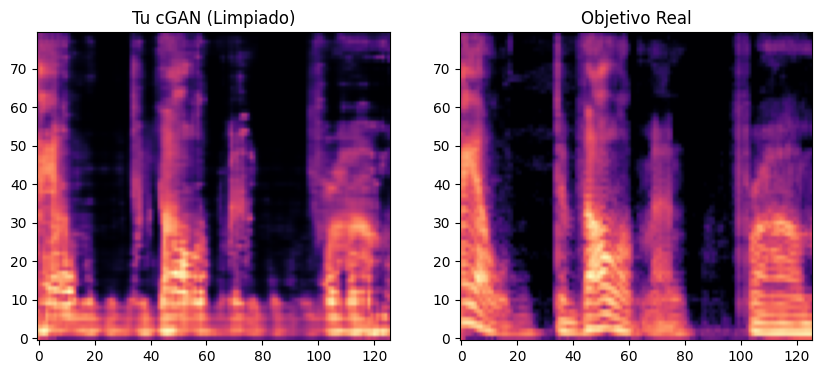

In [43]:
import random
import numpy as np
import IPython.display as ipd
import matplotlib.pyplot as plt

# 1. Seleccionar un índice aleatorio de tu dataset
idx = random.randint(0, len(X_mel) - 1)

# Extraemos las muestras y le añadimos la dimensión del "batch" (1, 80, 128, 1) para Keras
mel_ruidoso_sample = np.expand_dims(X_mel[idx], axis=0)
mel_limpio_sample = np.expand_dims(Y_mel[idx], axis=0)

print(f"Muestra aleatoria seleccionada: {idx}")

# --- FASE 1: LIMPIEZA VISUAL (cGAN) ---
print("🧹 Limpiando el ruido con la cGAN...")
mel_limpio_predicho = generator_mel.predict(mel_ruidoso_sample)


# --- FASE 2: SINTETIZAR AUDIO (Vocoder) ---
print("\n🎶 Sintetizando el audio de tu predicción (cGAN + Vocoder)...")
# Usamos la función reconstruir_audio_con_vocoder() que ejecutaste en la celda anterior
audio_predicho = reconstruir_audio_con_vocoder(mel_limpio_predicho, ruta_salida="prueba_prediccion.wav")

print("\n🎯 Sintetizando el audio objetivo limpio (Para comparar)...")
audio_objetivo = reconstruir_audio_con_vocoder(mel_limpio_sample, ruta_salida="prueba_objetivo.wav")


# --- FASE 3: ESCUCHAR LOS RESULTADOS ---
print("-" * 40)
print("🎧 ESCUCHA LOS RESULTADOS:")

print("\n1️⃣ Audio Limpiado por tu Modelo (Lo que escuchará el usuario):")
display(ipd.Audio(audio_predicho, rate=16000))

print("\n2️⃣ Audio Objetivo (La máxima calidad que puede dar el Vocoder):")
display(ipd.Audio(audio_objetivo, rate=16000))

# (Opcional) Visualización rápida para ver que las matrices encajaban
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Tu cGAN (Limpiado)")
plt.imshow(np.squeeze(mel_limpio_predicho), origin='lower', aspect='auto', cmap='magma')
plt.subplot(1, 2, 2)
plt.title("Objetivo Real")
plt.imshow(np.squeeze(mel_limpio_sample), origin='lower', aspect='auto', cmap='magma')
plt.show()